In [2]:
import pickle as pkl
import numpy as np
from pathlib import Path
import tarfile
import glob
import re
from collections import defaultdict, Counter
import itertools
import matplotlib.pyplot as plt
import pandas as pd
# import dionysus

# from helper_functions import *
# from KK_zz_apex_LS import *

from hierarchicalsoftmax import SoftmaxNode, HierarchicalSoftmaxLoss, HierarchicalSoftmaxLinear
from hierarchicalsoftmax.inference import (
    greedy_predictions,
    node_probabilities,
)

import numpy as np
from collections import defaultdict, Counter
import itertools
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


/Users/levisvaren/anaconda3/envs/transformers/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the pickle files from Kritika and save for zigzag PH

{sequenc: {'sequence_id':id, 'mapped_label':label}}

Stratified 5-fold split based on superfamily labels
* if only order provided, then superfamily==order for sake of split

<80bp length removed

'>5% non atgc removed

**Should also remove if n superfamily < 5**

In [3]:
def process_pkl(mapped_data):
    # Save sequence and label
    sequences = []
    labels = []
    for k, value in mapped_data.items():
        sequences.append(k.lower())
        labels.append(value['mapped_label'])

    seq_x = [re.sub(r'[^atcg]', 'x', seq) for seq in sequences]

    # Create df, split labels into order and superfamily
    seq_df = pd.DataFrame({'sequence':sequences, 'seq_x':seq_x, 'labels':labels})
    seq_df[['order', 'superfamily']] = seq_df['labels'].str.split('/',expand=True) #split
    seq_df['superfamily'] = seq_df['superfamily'].fillna(seq_df['order']) # if only order, superfamily==order
    return seq_df, sequences, labels

def kfold_strat_split(seq_df, k=5, seed=7):
    # Split 
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    X = np.array(list(seq_df['seq_x']))
    # y = np.array(labels)
    y = np.array(list(seq_df['superfamily']))

    for fold_index, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        col_name = f'fold_{fold_index}'
        seq_df[col_name] = 'train' # Default everyone to train
        seq_df.loc[val_idx, col_name] = 'test'

    return seq_df

def kfold_split(seq_df, k=5, shuffle=True, seed=7):
    # Split 
    skf = KFold(n_splits=k, shuffle=True, random_state=seed)
    X = np.array(list(seq_df['seq_x']))
    y = np.array(list(seq_df['labels']))
    # y = np.array(list(seq_df['superfamily']))

    for fold_index, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        col_name = f'fold_{fold_index}'
        seq_df[col_name] = 'train' # Default everyone to train
        seq_df.loc[val_idx, col_name] = 'test'

    return seq_df

def get_seq_stats(seq_df):
    seq_df['seq_length'] = seq_df['seq_x'].str.len() # seq length
    seq_df['n_non_actg'] = seq_df['seq_x'].str.count('[^actg]') # number non canonical
    seq_df['frac_non_actg'] = seq_df['n_non_actg'] / seq_df['seq_length'] # fraction non canonical
    return seq_df

def filter_seqs(seq_df, len_thresh=80, frac_thresh=0.2): #kritika already did the len_thresh
    print(f"Original shape: {seq_df.shape}")
    seq_df_filt = seq_df[(seq_df['seq_length'] >= len_thresh) & (seq_df['frac_non_actg'] <= frac_thresh)]
    # Remove any labels with <5 sequences
    label_counts = Counter(seq_df_filt['labels'])
    to_remove = {label for label, count in label_counts.items() if count < 5}
    seq_df_filt = seq_df_filt[~seq_df_filt['labels'].isin(to_remove)]
    print(f"Removing these labels: {to_remove}")
    print(f"New shape: {seq_df_filt.shape}")
    return seq_df_filt.reset_index()

def save_fasta(filename, seq_df):
    sequences = list(seq_df['seq_x'])
    labels = list(seq_df['labels'])
    with open(filename, "w") as f:
        for i, (label, seq) in enumerate(zip(labels, sequences)):
            f.write(f">{i}_{label}\n")
            f.write(f"{seq.lower()}\n")
    print(f"Saved here: {filename}")

def split_fasta(input_file, path, chunk_size=1000):
    with open(input_file, 'r') as f:
        sequences = []
        current_seq = []
        file_count = 1
        
        for line in f:
            line = line.strip()
            if not line: continue
            
            if line.startswith('>'):
                # If we have a sequence buffered, join it and store it
                if current_seq:
                    sequences.append("".join(current_seq))
                    current_seq = []
                
                # Check if we need to save the current chunk
                if len(sequences) >= chunk_size:
                    save_chunk(sequences, path, file_count)
                    sequences = []
                    file_count += 1
            else:
                current_seq.append(line)

        # Handle the very last sequence in the file
        if current_seq:
            sequences.append("".join(current_seq))
        
        # Save the final remaining chunk
        if sequences:
            save_chunk(sequences, path, file_count)

def save_chunk(data, path, count):
    output_name = f"{path}/chunk_{count}.txt"
    with open(output_name, 'w') as out:
        out.write("\n".join(data) + "\n")
    # print(f"Saved {output_name}")

In [16]:
all_labels = []

### Repbase

In [40]:
# Load data
pkl_path = "./../TERRIER_labellingsystems_alldatasets"
dataset = "RepBase31pt04_converted2_terrierlabelsMay13.pkl"
db_path = f"{pkl_path}/{dataset}"

filename = '../repbase_QC_051326.fasta'
save_path = '../Repbase/'

csv_save = '../repbase_QC_051326.csv'

with open(db_path, "rb") as f:
    mapped_data = pkl.load(f)

seq_df, sequences, labels = process_pkl(mapped_data)
all_labels.extend(labels)

# Filter
seq_df = get_seq_stats(seq_df)
seq_df = filter_seqs(seq_df, len_thresh=80, frac_thresh=0.2)

# Stratified split
seq_df = kfold_strat_split(seq_df, k=5, seed=7)
# seq_df = kfold_split(seq_df)

# Save df 
seq_df['dataset'] = 'Repbase'
seq_df.to_csv(csv_save, index=False)

# # Save big fasta
# save_fasta(filename, seq_df)

# # Save chunks
# output_dir = Path(save_path)
# output_dir.mkdir(parents=True, exist_ok=True)
# split_fasta(filename, save_path, 5000)


Original shape: (116787, 8)
Removing these labels: set()
New shape: (116766, 8)


In [4]:
seq_df['labels'].value_counts()

labels
LTR/Gypsy           36310
LTR/Copia           11906
LTR/ERV              9442
LTR/Pao              8566
DNA/hAT              7672
LINE/L1              5429
DNA/TcMar            5204
DNA/Harbinger        2812
DNA/MULE             2758
SINE/tRNA            2547
DNA                  2371
RC/Helitron          2137
LTR/DIRS             2028
LINE/RTE             1762
DNA/CMC              1740
PLE                  1521
LINE/CR1             1334
LINE/I               1131
LINE/L2              1088
LTR                  1074
DNA/Kolobok           972
DNA/PiggyBac          701
LINE/Tad1             689
DNA/Academ            652
Satellite             574
LINE                  444
LINE/R1               419
DNA/Sola              413
DNA/P                 348
LINE/R2               345
DNA/Crypton           296
DNA/Maverick          264
LTR/Caulimovirus      216
SINE/7SL              192
DNA/Merlin            187
LINE/Rex-Babar        180
DNA/Dada              169
DNA/IS3EU             126
DNA/Z

### RepetDB

In [42]:
# Load data
pkl_path = "./../TERRIER_labellingsystems_alldatasets"
dataset = "Repetdb_allfiltered_terrier_May13.pkl"
db_path = f"{pkl_path}/{dataset}"

filename = '../repetdb_QC_051326.fasta'
save_path = '../RepetDB/'

csv_save = '../repetdb_QC_051326.csv'

with open(db_path, "rb") as f:
    mapped_data = pkl.load(f)

seq_df, sequences, labels = process_pkl(mapped_data)
all_labels.extend(labels)

# Filter
seq_df = get_seq_stats(seq_df)
seq_df = filter_seqs(seq_df, len_thresh=80, frac_thresh=0.2)

# Stratified split
seq_df = kfold_strat_split(seq_df, k=5, seed=7)
# seq_df = kfold_split(seq_df)

# Save df 
seq_df['dataset'] = 'RepetDB'
seq_df.to_csv(csv_save, index=False)

# # Save big fasta
# save_fasta(filename, seq_df)

# # Save chunks
# output_dir = Path(save_path)
# output_dir.mkdir(parents=True, exist_ok=True)
# split_fasta(filename, save_path, 5000)

Original shape: (73155, 8)
Removing these labels: {'RC/Helitron'}
New shape: (73153, 8)


In [6]:
seq_df['labels'].value_counts()

labels
LTR/Gypsy        46710
LTR/Copia        25444
DNA/hAT            386
DNA/Harbinger      271
DNA/TcMar          206
DNA/CMC             98
LINE/I              38
Name: count, dtype: int64

### MnTEdb

In [43]:
# Load data
pkl_path = "./../TERRIER_labellingsystems_alldatasets"
dataset = "MnTEdb_terrier.pkl"
db_path = f"{pkl_path}/{dataset}"

filename = '../mntedb_QC_051326.fasta'
save_path = '../MnTEdb/'

csv_save = '../mntedb_QC_051326.csv'

with open(db_path, "rb") as f:
    mapped_data = pkl.load(f)

seq_df, sequences, labels = process_pkl(mapped_data)
all_labels.extend(labels)

# Filter
seq_df = get_seq_stats(seq_df)
seq_df = filter_seqs(seq_df, len_thresh=80, frac_thresh=0.2)

# Stratified split
seq_df = kfold_strat_split(seq_df, k=5, seed=7)
# seq_df = kfold_split(seq_df)

# Save df 
seq_df['dataset'] = 'MnTEdb'
seq_df.to_csv(csv_save, index=False)

# # Save big fasta
# save_fasta(filename, seq_df)

# # Save chunks
# output_dir = Path(save_path)
# output_dir.mkdir(parents=True, exist_ok=True)
# split_fasta(filename, save_path, 5000)

Original shape: (5372, 8)
Removing these labels: set()
New shape: (4927, 8)


In [8]:
seq_df['labels'].value_counts()

labels
LTR/Copia        1426
LTR/Gypsy        1298
DNA/hAT          1041
LTR               840
DNA/Harbinger     272
RC/Helitron        31
LINE/L1            19
Name: count, dtype: int64

In [24]:
all_labels = list(set(all_labels))

['DNA/Harbinger',
 'DNA/Maverick',
 'SINE/tRNA',
 'SINE',
 'DNA/Merlin',
 'DNA/TcMar',
 'DNA/P',
 'LINE',
 'DNA/Ginger',
 'DNA/IS3EU',
 'LTR/Copia',
 'DNA/PiggyBac',
 'LTR/Caulimovirus',
 'DNA',
 'LINE/Rex-Babar',
 'DNA/CMC',
 'Satellite',
 'DNA/Crypton',
 'DNA/hAT',
 'DNA/Zator',
 'LINE/Dong-R4',
 'DNA/Sola',
 'LINE/Tad1',
 'SINE/U',
 'LINE/L1',
 'SINE/5S',
 'LTR/Gypsy',
 'LINE/R1',
 'DNA/Zisupton',
 'LINE/Proto2',
 'LINE/L2',
 'LTR',
 'DNA/Kolobok',
 'LINE/Dualen',
 'Structural_RNA',
 'DNA/Dada',
 'DNA/Novosib',
 'DNA/MULE',
 'LTR/Pao',
 'LINE/I',
 'Other',
 'DNA/Academ',
 'LINE/Proto1',
 'LTR/DIRS',
 'LINE/R2',
 'RC/Helitron',
 'SINE/7SL',
 'LINE/CR1',
 'LINE/RTE',
 'LINE/CRE',
 'LTR/ERV',
 'PLE']

In [31]:
ORDER_TO_SUPERFAMILIES = defaultdict(list)

In [ ]:
for l in all_labels:
    order_super = l.split('/')
    if len(order_super) == 2:
        ORDER_TO_SUPERFAMILIES[order_super[0]].append(order_super[1])
    elif len(order_super) == 1:
        ORDER_TO_SUPERFAMILIES[order_super[0]].append('')
for order, super in ORDER_TO_SUPERFAMILIES.items():
    ORDER_TO_SUPERFAMILIES[order] = list(set(super))

ORDER_TO_SUPERFAMILIES

In [44]:
pd.read_csv('../mntedb_QC_051326.csv')


,index,sequence,seq_x,labels,order,superfamily,seq_length,n_non_actg,frac_non_actg,fold_0,fold_1,fold_2,fold_3,fold_4,dataset
0,0,tgttgatgtcatagctgactgctgacctagtgtaattagtggcaga...,tgttgatgtcatagctgactgctgacctagtgtaattagtggcaga...,LTR/Copia,LTR,Copia,4872,0,0.0,train,train,train,test,train,MnTEdb
1,1,tgtgaaaaattgagaaagaactagaatatttctcattgaatcatga...,tgtgaaaaattgagaaagaactagaatatttctcattgaatcatga...,LTR/Copia,LTR,Copia,5007,0,0.0,train,test,train,train,train,MnTEdb
2,2,tgtcagaaatataggagtagataggtttagatatggtttatgcgtt...,tgtcagaaatataggagtagataggtttagatatggtttatgcgtt...,LTR/Copia,LTR,Copia,5026,0,0.0,train,train,test,train,train,MnTEdb
3,3,tgttgagatttccaaatcaattagggaagattcctaagaattatcc...,tgttgagatttccaaatcaattagggaagattcctaagaattatcc...,LTR/Copia,LTR,Copia,5238,0,0.0,train,train,train,test,train,MnTEdb
4,4,tggaggagaaaaacaatgtgaactttgctattattaatcagaaaac...,tggaggagaaaaacaatgtgaactttgctattattaatcagaaaac...,LTR/Copia,LTR,Copia,9961,0,0.0,train,test,train,train,train,MnTEdb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4922,5367,tgttaggtatttttattagttggcaatttattggcaatcttgtaaa...,tgttaggtatttttattagttggcaatttattggcaatcttgtaaa...,LTR,LTR,LTR,4230,0,0.0,train,train,test,train,train,MnTEdb
4923,5368,tgatgtagctcctgctaccagaaaggagagataatttttatcttta...,tgatgtagctcctgctaccagaaaggagagataatttttatcttta...,LTR,LTR,LTR,5262,0,0.0,train,train,train,test,train,MnTEdb
4924,5369,tctttgagagtacgagagttgtagttagccaacttgtctacatcaa...,tctttgagagtacgagagttgtagttagccaacttgtctacatcaa...,LTR,LTR,LTR,6871,0,0.0,train,train,train,test,train,MnTEdb
4925,5370,tgttaggactgtttttgttcctgatgtcacagagagtgttataaca...,tgttaggactgtttttgttcctgatgtcacagagagtgttataaca...,LTR,LTR,LTR,5404,0,0.0,test,train,train,train,train,MnTEdb


In [38]:
ORDER_TO_SUPERFAMILIES = {
    'LTR': ['','ERV','Pao','Gypsy','DIRS','Caulimovirus','Copia'],
    'DNA': ['','PiggyBac','Ginger','Academ','Crypton','Sola','CMC',
              'IS3EU','Novosib','Harbinger','P','hAT','Maverick',
              'Dada','Zator','Kolobok','Merlin','MULE','Zisupton','TcMar'],
    'LINE': ['','CRE','Proto1','Rex-Babar','L2','Tad1','Proto2','I',
              'RTE','Dualen','Dong-R4','CR1','R2','L1','R1'],
    'Satellite': [''],
    'RC': ['Helitron'],
    'SINE': ['', 'U', '7SL', 'tRNA', '5S'],
    'Structural_RNA': [''],
    'PLE': [''],
    'Other': ['']}

# Prep test files for preML processing 

1. Homo sapiens

2. Mus musculus

3. Oryza sativa

4. Drosophila melanogaster

In [95]:
superfam_mapping = {
    "I-Jockey": "I",
    "TcMar-Pogo": "TcMar",
    "TcMar-Tc1": "TcMar",
    "CMC-Transib": "CMC",
    "R1-LOA": "R1",
    "hAT-hobo": "hAT",
    "hAT-Tip100": "hAT",
    "CMC-EnSpm": "CMC",
    "RC": "Helitron",
    "Mariner-Tc1": "TcMar",
    "Dirs": "DIRS",
    "Pao": "Bel-Pao",
    "DNA": "TIR",
    "CMC-.*": "CACTA",
    "Tc1-.*": "Tc1",
    "hAT-.*": "hAT",
    "ERV.*": "ERV",
    "L1-.*": "L1",
    "PIF-Harbinger": "PIF",
    "Crypton-.*": "Crypton",
    "RTE-.*": "RTE",
    "Retroposon": "LINE",
    "MULE-.*": "MULE",
    "R1-.*": "R1",
    "tRNA-.*": "SINE2/tRNA",
    "5S-.*": "SINE3/5S",
    "Alu": "SINE1/7SL",
    "B2": "SINE2/tRNA",
    "B4": "SINE2/tRNA",
    "MIR": "SINE2/tRNA",
    "ID": "SINE2/tRNA",
    "Penelope": "PLE",
    "Unknown": ""
}

def regex_map(val):
    if not isinstance(val, str):
        return val
        
    for pattern, replacement in superfam_mapping.items():
        # Match pattern from the beginning of the string
        if re.match(f"^{pattern}$", val) or re.match(pattern, val):
            return replacement
            
    # Fallback if no patterns match
    return val

In [99]:
# Save fastas as chunk.txt files
test_dir = '/Users/levisvaren/Downloads/040326/051926/Test_files/'
test_files = glob.glob(f"{test_dir}/*fasta")

df = pd.DataFrame(columns=['sequence', 'seq_x', 'og_header', 'og_label', 'dataset'])

for i, file in enumerate(test_files):
    new_dir = file.replace('.fasta', '')
    ds = new_dir.replace(test_dir, '')

    # Generate labels
    headers = []
    sequences = []

    current_sequence = []

    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # Skip empty lines
            
            if line.startswith(">"):
                if current_sequence:
                    sequences.append("".join(current_sequence))
                    current_sequence = []
                headers.append(line[1:])
            else:
                current_sequence.append(line)
        # last sequence
        if current_sequence:
            sequences.append("".join(current_sequence))

    # Extract the labels
    labels = [h.split('#')[-1] for h in headers] 

    # change non atcg to x
    seq_x = [re.sub(r'[^atcg]', 'x', seq.lower()) for seq in sequences]

    df_tmp = pd.DataFrame(
        {'sequence':sequences, 
        'seq_x': seq_x,
        'og_header':headers, 
        'og_label':labels, 
        'dataset':ds})
    df_tmp = get_seq_stats(df_tmp)

    df = pd.concat([df, df_tmp], ignore_index=True)

    print(f"Dataset: {ds} ({i+1})")
    print(f"Max non-canonical %: {df_tmp['frac_non_actg'].max()}")
    print(seq_x[0])
    
    # with open(f"{test_dir}/chunk_{i+1}.txt", "w") as f:
    #     for seq in seq_x:
    #         f.write(seq + "\n")


Dataset: Homo_sapiens (1)
Max non-canonical %: 0.3651315789473684
...
Dataset: Mus_musculus (2)
Max non-canonical %: 0.3651315789473684
aaaaaaattccacaaggagctcaagtactttgccattcatggaattgcacttgagtgttccacacatactcaagatgtggtagaatcacttaagtcctccaaagggactctactttacttctgcacaaagtgaactagaaccataggcaacttccccaggcgttatgataaattctcattctgtcagggggccaagaagattatccccctctatggaacagattcaaagacaattcttaagttttctctaccacagaaaggaagattatatcattctcctgctatgaaatgtgacacaaacattgtcattctagtagaagactgaaagatgctctgtccaaacaatgggtcttcagaaagtcctgatctgatcaagaattattcagatatctcttatcagccaaaagagccctcttgatttgtcagcaggccccaaacacctgagagattattccaaaacacttccagtgagataaacaatttcaatatttgtcgtagaatacacaactaagaggatatcaccctctcagctgccactgggcacactagaggctgtgaagaattccccatatatgtccaagtttctaggatttccaaaacctgtacaggactctctgcatactactctatcacataaagggactgtaggacaggataaatctacagaagagagttctagccacagtcccatctttagaaatggctcatggatatgatacatcttcaaaagatgttctaggacagattccatctgtaaagaagggtctggatccaatcctatgtgaacatggtgctatcggatgtgatttgcacgcacaagagtctggagcatcctgtacagcccaaagaagggaattccatgta

In [100]:
df[['order', 'superfamily']] = df['og_label'].str.split('/',expand=True)
df['mapped_super'] = df['superfamily'].apply(regex_map)
df

,sequence,seq_x,og_header,og_label,dataset,seq_length,n_non_actg,frac_non_actg,order,superfamily,mapped_super
0,AATGGAATGGAATGGAATGGAATGGAATGGAATGGAATGGAATGGA...,aatggaatggaatggaatggaatggaatggaatggaatggaatgga...,NODE_Basic_0_Length_20016#Simple_repeat,Simple_repeat,Homo_sapiens,20016.0,0.0,0.000000,Simple_repeat,None,None
1,TCTTTGTGATGTGTGCATTCATCTCACAGAGTTGAACTTTTCTTTT...,tctttgtgatgtgtgcattcatctcacagagttgaacttttctttt...,NODE_Basic_1_Length_19690#Satellite/Y-chromosome,Satellite/Y-chromosome,Homo_sapiens,19690.0,0.0,0.000000,Satellite,Y-chromosome,Y-chromosome
2,ATATCTTCACATAAAAACTAGACAGAAGCATTCTCAGAAACTTCTT...,atatcttcacataaaaactagacagaagcattctcagaaacttctt...,NODE_Basic_2_Length_19332#Satellite/Y-chromosome,Satellite/Y-chromosome,Homo_sapiens,19332.0,0.0,0.000000,Satellite,Y-chromosome,Y-chromosome
3,CCTACCAATCACCTTGATGAGAAAACCAAGACCAGCCTGAAGGCGA...,cctaccaatcaccttgatgagaaaaccaagaccagcctgaaggcga...,NODE_Basic_3_Length_18447#LINE/L2,LINE/L2,Homo_sapiens,18447.0,0.0,0.000000,LINE,L2,L2
4,AGCATTCTGTGAAACTTGTTTGTGATGTGTGTACTCAACTAACAGT...,agcattctgtgaaacttgtttgtgatgtgtgtactcaactaacagt...,NODE_Basic_4_Length_18206#Satellite/Y-chromosome,Satellite/Y-chromosome,Homo_sapiens,18206.0,0.0,0.000000,Satellite,Y-chromosome,Y-chromosome
...,...,...,...,...,...,...,...,...,...,...,...
4129,TCCATTCATGAAGACGCTGCTGTTGCCGCTGCGGCTGNTGCTGCTG...,tccattcatgaagacgctgctgttgccgctgcggctgxtgctgctg...,rnd-6_family-22#Unknown,Unknown,Drosophila_melanogaster,374.0,5.0,0.013369,Unknown,None,None
4130,CAAAGACCCTAGAATAACAAGATGCGTAACGCCATACGATTTTTTG...,caaagaccctagaataacaagatgcgtaacgccatacgattttttg...,rnd-6_family-230#DNA/P,DNA/P,Drosophila_melanogaster,1113.0,2.0,0.001797,DNA,P,P
4131,TATACCCGTTACTCGTAGAGTAAAAGGGTATACTAGATTCGTTGAA...,tatacccgttactcgtagagtaaaagggtatactagattcgttgaa...,rnd-6_family-61#RC/Helitron,RC/Helitron,Drosophila_melanogaster,667.0,20.0,0.029985,RC,Helitron,Helitron
4132,TCAACAGCATAAAGAAACTGGTCCAATATCGTTAAGAGATGAAATA...,tcaacagcataaagaaactggtccaatatcgttaagagatgaaata...,rnd-6_family-164#LTR/Gypsy,LTR/Gypsy,Drosophila_melanogaster,3442.0,25.0,0.007263,LTR,Gypsy,Gypsy


In [101]:
df['superfamily'].value_counts()

superfamily
L1              522
ERV1            467
Gypsy           437
ERVK            400
ERVL            247
               ... 
subtelomeric      2
hAT-hobo          1
7SL               1
telomeric         1
R2                1
Name: count, Length: 64, dtype: int64

# Results

In [ ]:
import os
import tarfile
import pickle
import glob
import io
import sys

os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_cache"
os.environ["USER"] = "researcher"
os.environ["LOGNAME"] = "researcher"

from hierarchicalsoftmax import SoftmaxNode, HierarchicalSoftmaxLoss, HierarchicalSoftmaxLinear
from hierarchicalsoftmax.inference import (
    greedy_predictions,
    node_probabilities,
)

import numpy as np
from collections import defaultdict, Counter
import itertools
import pandas as pd

# import dionysus

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

In [ ]:
def build_classification_tree(
    order_to_superfamilies: dict,
    label_smoothing: float = 0.0,
    gamma: float = 0.0,
) -> SoftmaxNode:
    root = SoftmaxNode(
        "root",
        label_smoothing=label_smoothing,
        gamma=gamma,
    )
    for order_name, superfamily_list in order_to_superfamilies.items():
        order_node = SoftmaxNode(
            order_name,
            parent=root,
            label_smoothing=label_smoothing,
            gamma=gamma,
        )
        for sf_name in superfamily_list:
            SoftmaxNode(
                sf_name,
                parent=order_node,
                label_smoothing=label_smoothing,
                gamma=gamma,
            )
    root.set_indexes()
    return root


ORDER_TO_SUPERFAMILIES = {
    'LTR': ['','ERV','Pao','Gypsy','DIRS','Caulimovirus','Copia'],
    'DNA': ['','PiggyBac','Ginger','Academ','Crypton','Sola','CMC',
              'IS3EU','Novosib','Harbinger','P','hAT','Maverick',
              'Dada','Zator','Kolobok','Merlin','MULE','Zisupton','TcMar'],
    'LINE': ['','CRE','Proto1','Rex-Babar','L2','Tad1','Proto2','I',
              'RTE','Dualen','Dong-R4','CR1','R2','L1','R1'],
    'Satellite': [''],
    'RC': ['Helitron'],
    'SINE': ['', 'U', '7SL', 'tRNA', '5S'],
    'Structural_RNA': [''],
    'PLE': [''],
    'Other': ['']}

root = build_classification_tree(ORDER_TO_SUPERFAMILIES)

In [ ]:
# with open('/staging/s/svaren/terrier_zzformer/loss_200/MnTEdb_all_results.pkl', 'rb') as f:
# with open('/staging/s/svaren/terrier_zzformer/RepetDB_all_results.pkl', 'rb') as f:
with open('/staging/s/svaren/terrier_zzformer/Repbase_all_results.pkl', 'rb') as f:
    mntedb_cnn = pickle.load(f)



# Order
results = {}
for i in range(5):
    predictions = mntedb_cnn[f'fold_{i}']['pred_y_order']
    labels = mntedb_cnn[f'fold_{i}']['test_y']
    pred_string = [str(i) for i in predictions]
    # superfam = [item.split('/')[-1] for item in labels]
    order = [item.split('/')[0] for item in labels]
    report = classification_report(order, pred_string, digits=4)
    results[f'fold_{i}'] = report


for k, v in results.items():
    print(k)
    print(v)



# Superfamily
results = {}
for i in range(5):
    predictions = mntedb_cnn[f'fold_{i}']['pred_y_super']
    labels = mntedb_cnn[f'fold_{i}']['test_y']
    pred_string = [str(i) for i in predictions]
    superfam = [item.split('/')[-1] for item in labels]
    report = classification_report(superfam, pred_string, digits=4)
    results[f'fold_{i}'] = report

for k, v in results.items():
    print(k)
    print(v)

# Inference on all dataset with fold 5

In [ ]:
import os
import tarfile
import pickle
import glob
import io
import sys

os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_cache"
os.environ["USER"] = "researcher"
os.environ["LOGNAME"] = "researcher"

from hierarchicalsoftmax import SoftmaxNode, HierarchicalSoftmaxLoss, HierarchicalSoftmaxLinear
from hierarchicalsoftmax.inference import (
    greedy_predictions,
    node_probabilities,
)

import numpy as np
from collections import defaultdict, Counter
import itertools
import pandas as pd

# import dionysus

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

In [ ]:
def build_classification_tree(
    order_to_superfamilies: dict,
    label_smoothing: float = 0.0,
    gamma: float = 0.0,
) -> SoftmaxNode:
    root = SoftmaxNode(
        "root",
        label_smoothing=label_smoothing,
        gamma=gamma,
    )
    for order_name, superfamily_list in order_to_superfamilies.items():
        order_node = SoftmaxNode(
            order_name,
            parent=root,
            label_smoothing=label_smoothing,
            gamma=gamma,
        )
        for sf_name in superfamily_list:
            SoftmaxNode(
                sf_name,
                parent=order_node,
                label_smoothing=label_smoothing,
                gamma=gamma,
            )
    root.set_indexes()
    return root


ORDER_TO_SUPERFAMILIES = {
    'LTR': ['','ERV','Pao','Gypsy','DIRS','Caulimovirus','Copia'],
    'DNA': ['','PiggyBac','Ginger','Academ','Crypton','Sola','CMC',
              'IS3EU','Novosib','Harbinger','P','hAT','Maverick',
              'Dada','Zator','Kolobok','Merlin','MULE','Zisupton','TcMar'],
    'LINE': ['','CRE','Proto1','Rex-Babar','L2','Tad1','Proto2','I',
              'RTE','Dualen','Dong-R4','CR1','R2','L1','R1'],
    'Satellite': [''],
    'RC': ['Helitron'],
    'SINE': ['', 'U', '7SL', 'tRNA', '5S'],
    'Structural_RNA': [''],
    'PLE': [''],
    'Other': ['']}

root = build_classification_tree(ORDER_TO_SUPERFAMILIES)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_channels=5, n_filters=16):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            # 128 to 64
            nn.Conv2d(n_channels, n_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 64 to 32
            nn.Conv2d(n_filters, n_filters*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 32 to 16
            nn.Conv2d(n_filters*2, n_filters*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Average Pooling: set wanted output size, not kernel
            nn.AdaptiveAvgPool2d((1, 1)), # (64, 1, 1)
            nn.Flatten()                  # (64)
        )
    def forward(self, x):
        return self.encoder(x)

class HierarchicalCNN(nn.Module):
    def __init__(self, root_node, n_channels=5, n_filters=16):
        super(HierarchicalCNN, self).__init__()
        # These now return a vector of size 64 each (if n_filters=16)
        self.enc4 = Encoder(n_channels=n_channels, n_filters=n_filters)
        self.enc8 = Encoder(n_channels=n_channels, n_filters=n_filters)
        self.enc14 = Encoder(n_channels=n_channels, n_filters=n_filters)
        self.enc20 = Encoder(n_channels=n_channels, n_filters=n_filters) 
        # Calculate the concatenated size: (n_filters * 4) * 4 encoders
        combined_size = (n_filters * 4) * 4 
        self.prediction_head = nn.Sequential(
            nn.Linear(combined_size, 512), # 256 to 512
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
        )
        self.hierarchical_layer = HierarchicalSoftmaxLinear(
            in_features=512,
            root=root_node
        )
    def forward(self, x4, x8, x14, x20):
        # Your forward logic remains exactly the same!
        z4 = self.enc4(x4)
        z8 = self.enc8(x8)
        z14 = self.enc14(x14)
        z20 = self.enc20(x20)
        combined = torch.cat((z4, z8, z14, z20), dim=1)
        classification = self.prediction_head(combined)
        return self.hierarchical_layer(classification), combined
    

def get_PI(path):
    all_pkl = {}
    image_files = glob.glob(f"./{path}/*tar.gz")
    # print(image_files)
    for file in image_files:
        with tarfile.open(file, "r:gz") as tar:
            all_files = tar.getnames()
            pkl_path = next((f for f in all_files if f.endswith('.pkl')), None)
            if pkl_path:
                member = tar.getmember(pkl_path)
                f = tar.extractfile(member)
                data = pickle.load(f)
                all_pkl = all_pkl | data
    return all_pkl

def update_metadata(lookup, all_pkl):
    for seq, metadata in lookup.items():
        if seq in all_pkl:
            all_pkl[seq].update(metadata)
        else:
            all_pkl[seq] = {
                **metadata,
                'persistence_image': np.zeros((128,128,5)) #add 0 if none
            }
    return all_pkl

In [ ]:
device = torch.device('cuda')

model = HierarchicalCNN(root_node=root).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Load model
save_path = '/staging/s/svaren/terrier_zzformer/MnTEdb_f4.pth' #Repbase_f4, RepetDB_f4
checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])



In [ ]:
# Load data
labels_path = ''
labels = pd.read_csv(labels_path) # labels
label_map = build_label_to_node_id(root)


labels['label_id'] = labels['labels'].map(label_map)
lookup = labels.drop_duplicates('seq_x').set_index('seq_x')[['label_id', 'labels', 'dataset']].to_dict('index')

pi_paths = [f'{pi_dir}/4mer', f'{pi_dir}/8mer', f'{pi_dir}/14mer', f'{pi_dir}/20mer']

all_pkl = {}
train_images = []

for p in pi_paths:
    pkl_file = get_PI(p)
    pkl_file = update_metadata(lookup, pkl_file)
    folds = {}
    for i in range(5):
        train = labels[labels[f'fold_{i}'] == 'train']
        test = labels[labels[f'fold_{i}'] == 'test']
        train_lookup = train.drop_duplicates('seq_x').set_index('seq_x')[['label_id', 'labels',f'fold_{i}', 'dataset']].to_dict('index')
        test_lookup = test.drop_duplicates('seq_x').set_index('seq_x')[['label_id', 'labels',f'fold_{i}', 'dataset']].to_dict('index')
        train, test = get_train_test(all_pkl, train_lookup, test_lookup)
        train, test = dataloader_ready(train, test, i)

        folds[f'split_{i}'] = {'train': train, 'test': test}
    all_pkl[p] = folds # for given database, all the splits for all kmers







In [ ]:
order_preds = []
super_preds = []
trues = []
outss = []
z = []


model.eval() 

with torch.no_grad():
    for x4, x8, x14, x20, seq, ids, label, d in test_loader:
        x4 = x4.to(device)
        x8 = x8.to(device)
        x14 = x14.to(device)
        x20 = x20.to(device)
        outputs, embeddings = model(x4, x8, x14, x20)
        order_predicts = greedy_predictions(outputs, max_depth=1,root=root)
        superfam_preds = greedy_predictions(outputs, root=root)

        outss.extend(outputs)
        order_preds.extend(order_predicts)
        super_preds.extend(superfam_preds)
        trues.extend(label)
        z.append(embeddings)

In [ ]:
superfamily_colors_new = {
    # LTR-like / retroviral group: blues
    "Pao": "#eff3ff",          # old Bel-Pao
    "Copia": "#bdd7e7",
    "ERV": "#6baed6",
    "Gypsy": "#2171b5",
    "DIRS": "#ffff33",         # kept from old order_colors
    "Caulimovirus": "#084594",
 
    # DNA / former TIR-like group: oranges/browns
    "CMC": "#feedde",          # old CACTA-like color
    "TcMar": "#fdbe85",
    "hAT": "#fd8d3c",
    "MULE": "#e6550d",         # old MuLE
    "Harbinger": "#a63603",    # old PIF
    
    # New DNA superfamilies: related orange/brown shades
    "P": "#fdd0a2",
    "PiggyBac": "#fdae6b",
    "Zator": "#e34a33",
    "Merlin": "#b30000",
    "Kolobok": "#7f2704",
    "Maverick": "#d94801",
    "Novosib": "#8c2d04",
    "Zisupton": "#cc4c02",
    "Crypton": "#993404",
    "Academ": "#ec7014",
    "IS3EU": "#fe9929",
    "Dada": "#d95f0e",
    "Sola": "#f16913",
    "Ginger": "#a63603",
 
    # LINE group: purples
    "CR1": "#f2f0f7",
    "I": "#dadaeb",
    "L1": "#9e9ac8",
    "R2": "#807dba",
    "RTE": "#6a51a3",
    "R1": "#cbc9e2",
    "L2": "#756bb1",
    "Dong-R4": "#54278f",
    "Dualen": "#3f007d",
    "CRE": "#bcbddc",
    "Tad1": "#9e9ac8",
    "Rex-Babar": "#4a1486",
    "Proto2": "#6a51a3",
    "Proto1": "#807dba",
 
    # SINE group: greens
    "tRNA": "#74c476",         # old SINE2/tRNA
    "5S": "#238b45",           # old SINE3/5S
    "7SL": "#bae4b3",          # old SINE1/7SL
    "U": "#edf8e9",
 
    # RC / Helitron
    "Helitron": "#e41a1c",
 
    # Empty / non-superfamily groups
    "No superfamily": "gray",
}
 
order_colors_new = {
    "LTR": "#377eb8",
    "DNA": "#ff7f00",           # old TIR color
    "LINE": "#984ea3",
    "SINE": "#4daf4a",
    "RC": "#e41a1c",            # old Helitron color
    "PLE": "#a65628",
 
    # New broad categories
    "Satellite": "#999999",
    "Structural_RNA": "#66c2a5",
    "Other": "#bdbdbd",
}

In [ ]:
import matplotlib.pyplot as plt


checkpoint_path = "/staging/svaren/terrier_zzformer/MnTEdb_f0.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
loss = checkpoint['loss']


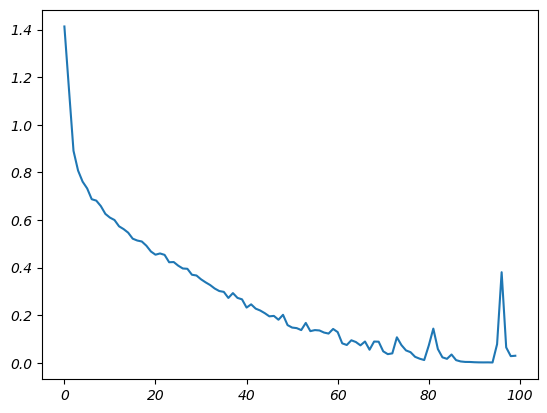

In [4]:
mntedb_0_loss = {0: 1.4130588918924332, 1: 1.1501400355369813, 2: 0.8904027423310664, 3: 0.8075577212918189, 4: 0.7608612634001239, 5: 0.7323038356919442, 6: 0.6870475577250603, 7: 0.681200907595696, 8: 0.6582018242728326, 9: 0.6253120482208268, 10: 0.6097243817583207, 11: 0.5996299162507057, 12: 0.5731654501249713, 13: 0.5614593129965567, 14: 0.5464969625876795, 15: 0.5211861528936894, 16: 0.5134153958530195, 17: 0.5093214145350841, 18: 0.49165254206426684, 19: 0.46727854385972023, 20: 0.45387107302104274, 21: 0.4591139549269311, 22: 0.4531186751780971, 23: 0.4221106464824369, 24: 0.4229972015225118, 25: 0.4076593103668382, 26: 0.3959323360073951, 27: 0.3946327164528831, 28: 0.3696650001671045, 29: 0.36643902524825067, 30: 0.3503907408204771, 31: 0.33770470312165635, 32: 0.32635832707127255, 33: 0.31175215097685016, 34: 0.30116820882164663, 35: 0.2976106408262445, 36: 0.272099647081397, 37: 0.29243484542014136, 38: 0.2723820174653684, 39: 0.26621389581311133, 40: 0.23160873469896615, 41: 0.2451732203124031, 42: 0.22717341028469346, 43: 0.21919200725613103, 44: 0.20802660773117695, 45: 0.19480654293851507, 46: 0.1966278051596976, 47: 0.18055051006423686, 48: 0.20117211622005748, 49: 0.15793141699396074, 50: 0.14762084177815385, 51: 0.14529646599605198, 52: 0.13703534741615575, 53: 0.16711519221444765, 54: 0.13261548990023234, 55: 0.13696303217101, 56: 0.13543905552116134, 57: 0.12667109615980618, 58: 0.12236716588508458, 59: 0.1417637657854826, 60: 0.12857539562748804, 61: 0.08129665321171013, 62: 0.07439267455089477, 63: 0.09418865545998298, 64: 0.08680118618494523, 65: 0.07282750687051204, 66: 0.08901980322139759, 67: 0.05447941218247457, 68: 0.08884556554332976, 69: 0.08818441537779666, 70: 0.04768334741651591, 71: 0.0358972113341048, 72: 0.03917411771480176, 73: 0.10669876303103182, 74: 0.07392998288701018, 75: 0.05162089156182183, 76: 0.04408073638314231, 77: 0.024608676131221377, 78: 0.016753641718500766, 79: 0.011217040581546062, 80: 0.07205468446209712, 81: 0.14322241857148438, 82: 0.05725137739406613, 83: 0.022486073622149567, 84: 0.016203515176218184, 85: 0.03433651799564212, 86: 0.01068211870804061, 87: 0.0051976088518366, 88: 0.0032114876765908483, 89: 0.0030462438542438195, 90: 0.001919375396482792, 91: 0.0013576211664668894, 92: 0.0011737341385836067, 93: 0.0013357097566533353, 94: 0.0008768532163612103, 95: 0.07784479386924842, 96: 0.38023303108169665, 97: 0.06425490737761251, 98: 0.027564119218075046, 99: 0.029133949019934893}

plt.plot(list(mntedb_0_loss.keys()), list(mntedb_0_loss.values()))
plt.show()

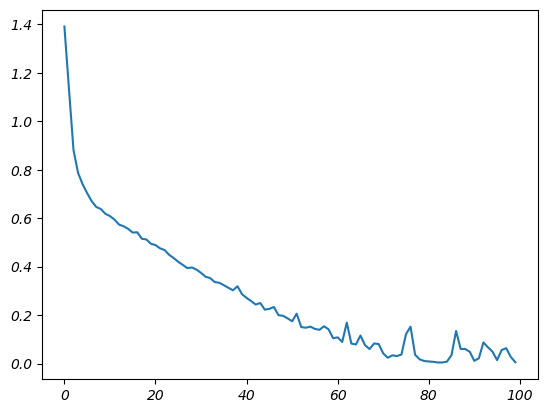

In [5]:
mntedb_1_loss = {0: 1.3914650827646255, 1: 1.134463571733044, 2: 0.881203314710048, 3: 0.786902665370895, 4: 0.7402112717109341, 5: 0.7030988941269536, 6: 0.6699099985341872, 7: 0.6462074864295221, 8: 0.6378727656218314, 9: 0.6180212671958631, 10: 0.6087897828509731, 11: 0.5940781190030037, 12: 0.5735919413066679, 13: 0.5666864370146105, 14: 0.5557507134733661, 15: 0.5405836628089028, 16: 0.5418616403495112, 17: 0.515102053121213, 18: 0.5121645262885478, 19: 0.4943899320017907, 20: 0.48905526762527807, 21: 0.4755579435056256, 22: 0.46834458122330325, 23: 0.4487158347281717, 24: 0.4352272342620117, 25: 0.41989331067569796, 26: 0.40703049764758154, 27: 0.39381413245874064, 28: 0.3964674248690567, 29: 0.38768012815665814, 30: 0.37424503675391596, 31: 0.3581551674513086, 32: 0.35288342160563313, 33: 0.33630961245827135, 34: 0.333291873095497, 35: 0.3233722666759164, 36: 0.3127394887588678, 37: 0.3022431159211743, 38: 0.3189689692470335, 39: 0.28629945140452157, 40: 0.2708167309962934, 41: 0.2578023595795516, 42: 0.24343672162297392, 43: 0.2498902683596938, 44: 0.22229579379481654, 45: 0.22562768851076404, 46: 0.23343499822001304, 47: 0.19957097652818886, 48: 0.19702709030600324, 49: 0.1864424096720834, 50: 0.17432179923860297, 51: 0.20573891136014172, 52: 0.1504024767975, 53: 0.1478392337448895, 54: 0.1521229802014967, 55: 0.14287606006368034, 56: 0.13913259767897188, 57: 0.15383201017374953, 58: 0.1410455444917804, 59: 0.10444138986208747, 60: 0.1079826672080784, 61: 0.08897487895803587, 62: 0.1690401776887161, 63: 0.08238890620639487, 64: 0.07841375962110056, 65: 0.11564269595058455, 66: 0.07588232831931824, 67: 0.05955057800747454, 68: 0.08275352234786917, 69: 0.0805419343763973, 70: 0.04169414249660012, 71: 0.023849469199288455, 72: 0.03366137273429382, 73: 0.030738118390041973, 74: 0.037181696406708306, 75: 0.12103868031033105, 76: 0.15203646648555033, 77: 0.03618307501563968, 78: 0.01726401590255386, 79: 0.010220948387511945, 80: 0.008441502821956565, 81: 0.006992452354038945, 82: 0.004258390705819047, 83: 0.004311518382535489, 84: 0.007866604045932857, 85: 0.034983600281374226, 86: 0.13432070809311322, 87: 0.06010280036923265, 88: 0.060044476117904956, 89: 0.048404089220228694, 90: 0.01106324891577148, 91: 0.021826883825387115, 92: 0.08693983157225434, 93: 0.06690757802566476, 94: 0.048743314068668685, 95: 0.013894665257999629, 96: 0.05537350240375681, 97: 0.0634229772460399, 98: 0.02744552428926146, 99: 0.005165623793800478}
plt.plot(list(mntedb_1_loss.keys()), list(mntedb_1_loss.values()))
plt.show()

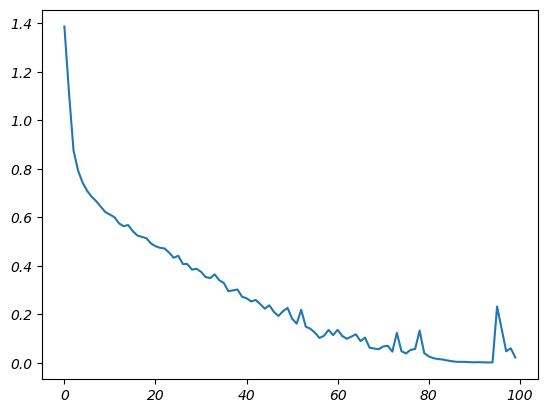

In [6]:
mntedb_2_loss = {0: 1.3867848847181565, 1: 1.1166625147865665, 2: 0.8763039376466505, 3: 0.7926237068829998, 4: 0.7425456820957123, 5: 0.7086127198511555, 6: 0.6845945574102863, 7: 0.6657405060625845, 8: 0.6431060267552253, 9: 0.6210700855139764, 10: 0.6107719756903187, 11: 0.6001327860980264, 12: 0.5746960624331429, 13: 0.5629259082338502, 14: 0.5677357549148221, 15: 0.5429854008459276, 16: 0.5248221279151978, 17: 0.5190936997532845, 18: 0.5134707826279825, 19: 0.4918647014325665, 20: 0.4804813056703537, 21: 0.4739683519207662, 22: 0.47105261274883825, 23: 0.4542274213125629, 24: 0.4328176520404316, 25: 0.44101849582887465, 26: 0.40719317290331086, 27: 0.40678579372263723, 28: 0.38382769003510475, 29: 0.3873623954432626, 30: 0.37496808063118686, 31: 0.3534896755290608, 32: 0.34893319527468375, 33: 0.3642720283279496, 34: 0.340180026607648, 35: 0.32896810036993795, 36: 0.29506768538586553, 37: 0.2983286375960996, 38: 0.3018851739264304, 39: 0.2723447711116845, 40: 0.26549203483568085, 41: 0.2525134474760102, 42: 0.25876213625193606, 43: 0.24168110308387586, 44: 0.22298721803893004, 45: 0.2367024379932592, 46: 0.20935291769884287, 47: 0.19287931949140563, 48: 0.2124319512757563, 49: 0.22597338902133127, 50: 0.18136128296534862, 51: 0.1612262823769162, 52: 0.21798066885000275, 53: 0.14850224335227283, 54: 0.14002329928259696, 55: 0.12401545133381602, 56: 0.10196398389375498, 57: 0.11127996646739062, 58: 0.13521901735915773, 59: 0.11397852537582719, 60: 0.1354321111594477, 61: 0.11027557188795219, 62: 0.0988267722779945, 63: 0.10759130730988428, 64: 0.11702863236648901, 65: 0.08899226645758797, 66: 0.10351620885663695, 67: 0.061982678279521, 68: 0.058542432584574505, 69: 0.05548267884765782, 70: 0.06708062118512668, 71: 0.06967606484856824, 72: 0.04562394452401467, 73: 0.1230502690023352, 74: 0.04762974284277598, 75: 0.03798088177497829, 76: 0.052907136592341794, 77: 0.056331997630261484, 78: 0.13241610543111398, 79: 0.039370245560290174, 80: 0.02604608168645251, 81: 0.018814126382142516, 82: 0.015100728248193439, 83: 0.01335850518901885, 84: 0.009456483738411466, 85: 0.0063854165792074655, 86: 0.003864282184358378, 87: 0.0035441726195717966, 88: 0.003404307902171915, 89: 0.001954603173456383, 90: 0.001779278559825475, 91: 0.0020638030554466476, 92: 0.0014529584879065009, 93: 0.0009414662099956213, 94: 0.001300185077349353, 95: 0.23160035042688362, 96: 0.13936541581736697, 97: 0.04727825437927799, 98: 0.05930057923204356, 99: 0.021723736163919732}
plt.plot(list(mntedb_2_loss.keys()), list(mntedb_2_loss.values()))
plt.show()

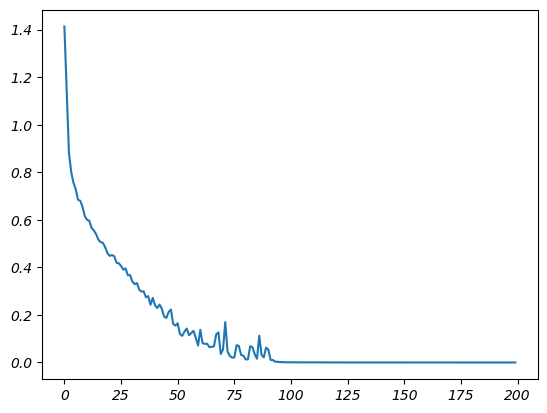

In [7]:
loss200 = {0: 1.4130585597407432, 1: 1.1475025876875846, 2: 0.8822192190395247, 3: 0.801399941886625, 4: 0.7558245306774494, 5: 0.7288107910463887, 6: 0.68448362595612, 7: 0.6800439588485225, 8: 0.6543625311986092, 9: 0.6157627867594841, 10: 0.599853666319001, 11: 0.5956458432539817, 12: 0.5655858934886994, 13: 0.555268305924631, 14: 0.5394642856572905, 15: 0.516517601666912, 16: 0.5060153004503057, 17: 0.5035073731935793, 18: 0.48471821063468534, 19: 0.4594369095660025, 20: 0.4482596547252709, 21: 0.45162344147120753, 22: 0.44704650426583903, 23: 0.41981775854383746, 24: 0.41705760528003016, 25: 0.4061761170385345, 26: 0.390297285972103, 27: 0.3957993695211987, 28: 0.36687708489837184, 29: 0.3676839314641491, 30: 0.3403164851329019, 31: 0.32937207499579074, 32: 0.33407807960024766, 33: 0.3065144670826773, 34: 0.2980849374566347, 35: 0.2990642027148316, 36: 0.2743201523816453, 37: 0.278997210124808, 38: 0.24257234237607447, 39: 0.2716724058432925, 40: 0.24068037429524045, 41: 0.22899094545432636, 42: 0.24347851155025343, 43: 0.22617880214426306, 44: 0.19322246376184687, 45: 0.18740996282788053, 46: 0.21234564281879895, 47: 0.2227006929460913, 48: 0.16260435366101803, 49: 0.15485026071509045, 50: 0.16490166752989735, 51: 0.1194980346687859, 52: 0.11206360806470676, 53: 0.1297876577178437, 54: 0.14244401472951135, 55: 0.11479051275959899, 56: 0.1238845260212979, 57: 0.1329680572924835, 58: 0.10306813039877001, 59: 0.07129093543100622, 60: 0.1372431862325738, 61: 0.08107770322476426, 62: 0.07826677185010104, 63: 0.07858515506414997, 64: 0.06447720424565036, 65: 0.06635447073964432, 66: 0.06725014986154894, 67: 0.1181625698753182, 68: 0.12639020853150154, 69: 0.03568555892000023, 70: 0.05443431043081106, 71: 0.16995657222615856, 72: 0.04636991404808096, 73: 0.027702981144219877, 74: 0.02040505893678675, 75: 0.021004055029005677, 76: 0.07277836744023877, 77: 0.06951202833536832, 78: 0.03147068425652187, 79: 0.02859597255977156, 80: 0.012847974908166384, 81: 0.013148962869954336, 82: 0.06854009146392796, 83: 0.06401819389242108, 84: 0.034629596647597106, 85: 0.015749364678706645, 86: 0.11283721303709993, 87: 0.03204002918585414, 88: 0.021224679809810985, 89: 0.06208307655047505, 90: 0.05452764395064855, 91: 0.010608360160609488, 92: 0.010332810618790737, 93: 0.003320637677520168, 94: 0.0030288148312050205, 95: 0.0017258974639844382, 96: 0.0012135555530661687, 97: 0.0010811791510223561, 98: 0.0008008619067749673, 99: 0.0006857763212136183, 100: 0.0006437160730955281, 101: 0.0006053939926032619, 102: 0.0005098097179641979, 103: 0.000413923342245154, 104: 0.0003755107996169265, 105: 0.00035910778079860687, 106: 0.000325679656502449, 107: 0.0002787942620471078, 108: 0.00025132643448951935, 109: 0.00023760489585261132, 110: 0.00021486591145408203, 111: 0.00019021722955732265, 112: 0.0001789854618377927, 113: 0.00015539107668825723, 114: 0.00014591659509454575, 115: 0.00012928897592151008, 116: 0.00011927646716186803, 117: 0.0001063097449418714, 118: 0.00010066310639462154, 119: 9.597105201552744e-05, 120: 9.325244566662792e-05, 121: 8.416131956415308e-05, 122: 7.339279569572981e-05, 123: 6.7364548138196e-05, 124: 6.31650950846242e-05, 125: 5.5219826111301844e-05, 126: 5.2076887827422156e-05, 127: 4.73373938179535e-05, 128: 4.433876255270954e-05, 129: 4.016130281291724e-05, 130: 3.8787677636359914e-05, 131: 3.5627929726674225e-05, 132: 3.449677116819775e-05, 133: 3.2393579268104546e-05, 134: 2.7504488318094622e-05, 135: 2.604033467113984e-05, 136: 2.2786392755568657e-05, 137: 2.1415733106820307e-05, 138: 2.0130563501102336e-05, 139: 1.8362953275916353e-05, 140: 1.7156950482257665e-05, 141: 1.5685023458808423e-05, 142: 1.4893544563539117e-05, 143: 1.4544154026907563e-05, 144: 1.27449359771202e-05, 145: 1.175823785703664e-05, 146: 1.1415665563722697e-05, 147: 1.0277751409450186e-05, 148: 9.577680290267527e-06, 149: 8.874434702798065e-06, 150: 9.04300532148051e-06, 151: 7.4105355409071284e-06, 152: 7.0311321106142e-06, 153: 6.297397990256433e-06, 154: 6.053848750756545e-06, 155: 5.552233806651525e-06, 156: 5.315489736912674e-06, 157: 4.871004597407957e-06, 158: 4.746625644106332e-06, 159: 4.291543744888178e-06, 160: 3.914621838384571e-06, 161: 4.076558379407039e-06, 162: 3.762151557166802e-06, 163: 3.1235312791595915e-06, 164: 2.9537891525398933e-06, 165: 2.713783509366771e-06, 166: 2.5805738492900057e-06, 167: 2.377882541652305e-06, 168: 2.2622194678526802e-06, 169: 2.062838968401727e-06, 170: 1.8221710574252828e-06, 171: 1.703244938092958e-06, 172: 1.6705223549677348e-06, 173: 1.5775427030490849e-06, 174: 1.4532679770695722e-06, 175: 1.3325830705854873e-06, 176: 1.2608472690857755e-06, 177: 1.1520057932966298e-06, 178: 1.1098857884936632e-06, 179: 9.89171377066287e-07, 180: 9.208909065843008e-07, 181: 8.607755761502744e-07, 182: 8.089839508464192e-07, 183: 7.325323152543037e-07, 184: 7.146446705232829e-07, 185: 6.579729123767919e-07, 186: 6.080306930346435e-07, 187: 5.646493706723185e-07, 188: 5.280573731112778e-07, 189: 4.930765555138759e-07, 190: 4.438789199427113e-07, 191: 4.37984330395056e-07, 192: 3.929509424086434e-07, 193: 3.7345926351406433e-07, 194: 3.376186625896911e-07, 195: 3.271998698167207e-07, 196: 3.305884625833202e-07, 197: 2.8026141061662344e-07, 198: 2.537398576843162e-07, 199: 2.483142097372656e-07}
plt.plot(list(loss200.keys()), list(loss200.values()))
plt.show()